# Common Task 1- Convolutional Auto-Encoder for Quark/Gluon Jet Classification

Each jet event in the dataset is a **3-channel image of size 125×125**, where the three channels represent physical detector signals:

| Channel | Detector | What it captures |
|---------|----------|------------------|
| ECAL | Electromagnetic Calorimeter | Energy from electrons & photons |
| HCAL | Hadronic Calorimeter | Energy from hadrons (protons, pions…) |
| Tracks | Tracker | Paths of charged particles |

An **Auto-Encoder** is a neural network trained to:
1. **Compress** the 3×125×125 image into a small latent vector (bottleneck)
2. **Reconstruct** the original image from that compressed vector



Since the network **must recreate its own input**, it is forced to learn the most meaningful structure in the data without any labels.
The latent vector z is a compact physics aware representation of the jet, useful for downstream tasks (GNN, clustering, anomaly detection).


| Library | Role |
|---------|------|
| `h5py` | Read the HDF5 physics data file |
| `numpy` | Numerical array operations |
| `matplotlib` | All visualisations |
| `torch / torch.nn` | Define and train the neural network |
| `torch.optim` | Optimisers (AdamW) and schedulers |
| `Dataset / DataLoader` | Efficient batched data feeding |
| `sklearn.PCA` | 2-D projection of latent space |


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
import gc
import warnings
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla P100-PCIE-16GB
VRAM   : 17.1 GB


Hyperparameter Configuration
Centralise all tunable settings in one place so they are easy to change.

| Parameter | Value | Reasoning |
|-----------|-------|----------|
| `N_SAMPLES` | 30,000 | 30k × 3 × 125 × 125 × 4 bytes ≈ 5.6 GB - fits in Kaggle's 29 GB RAM |
| `BATCH_SIZE` | 64 | Balances GPU utilisation vs. gradient noise |
| `LATENT_DIM` | 256 | Compact enough to force meaningful compression; large enough for detail |
| `LR` | 1e-3 | Standard AdamW starting LR; scheduler will reduce it automatically |
| `EPOCHS` | 40 | Generous ceiling; early stopping will halt before this if needed |
| `TRAIN_R / VAL_R` | 75% / 15% | Standard 75/15/10 split |
| `SEED` | 42 | Reproducibility |

### Output
```
Config set.
```

In [2]:
HDF5_PATH  = '/kaggle/input/datasets/siddharthjaiswal23/datagsoc/quark-gluon_data-set_n139306.hdf5'
N_SAMPLES  = 30000
BATCH_SIZE = 64
LATENT_DIM = 256
LR         = 1e-3
EPOCHS     = 40
TRAIN_R    = 0.75
VAL_R      = 0.15
SAVE_PATH  = 'best_autoencoder.pth'
SEED       = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config set.')

Config set.


1. **`log1p` transform** - compresses the heavy-tailed energy distribution
2. **Per-channel min-max normalisation** - scales every channel to `[0, 1]`


Calorimeter energy deposits follow an extremely skewed distribution: mostly zeros with a few very large spikes. Raw values make gradients unstable.  
`log(1 + x)` compresses large values while preserving the zero baseline (since `log(1+0) = 0`).

### Output
```
Loading 30,000 / 139,306 samples into RAM …
  30,000/30,000
Done.  X: (30000, 3, 125, 125)  y: (30000,)
RAM used ≈ 5.62 GB
Label dist Gluon: 15,168  Quark: 14,832
```
- Shape `(30000, 3, 125, 125)` = 30k events × 3 channels × 125×125 pixels: correct PyTorch format
- **Near-equal class balance** (15168 gluon vs 14832 quark, ~50/50) the autoencoder won't be biased toward one class

In [4]:
def load_subset_to_ram(filepath, n_samples=30000, seed=42):
    rng = np.random.default_rng(seed)
    with h5py.File(filepath, 'r') as f:
        total   = f['X_jets'].shape[0]
        n       = min(n_samples, total)
        chosen  = np.sort(rng.choice(total, size=n, replace=False))
        print(f'Loading {n:,} / {total:,} samples into RAM …')
        CHUNK = 5000
        X_parts, y_parts = [], []
        for start in range(0, n, CHUNK):
            batch = chosen[start:start + CHUNK].tolist()
            X_parts.append(f['X_jets'][batch])
            y_parts.append(f['y'][batch])
            print(f'  {min(start + CHUNK, n):,}/{n:,}', end='\r')
    X = np.concatenate(X_parts, axis=0).astype(np.float32) 
    y = np.concatenate(y_parts, axis=0)
    X = X.transpose(0, 3, 1, 2) 
    X = np.log1p(X)             
    for c in range(3):          
        vmin = X[:, c].min()
        vmax = X[:, c].max()
        if vmax > vmin:
            X[:, c] = (X[:, c] - vmin) / (vmax - vmin)
    print(f'\nDone.  X: {X.shape}  y: {y.shape}')
    print(f'RAM used ≈ {X.nbytes / 1e9:.2f} GB')
    print(f'Label dist — Gluon: {(y==0).sum():,}  Quark: {(y==1).sum():,}')
    return X, y
X_all, y_all = load_subset_to_ram(HDF5_PATH, n_samples=N_SAMPLES, seed=SEED)

Loading 30,000 / 139,306 samples into RAM …
  30,000/30,000
Done.  X: (30000, 3, 125, 125)  y: (30000,)
RAM used ≈ 5.62 GB
Label dist — Gluon: 15,168  Quark: 14,832


Visualise Raw Jet Samples
Display the three detector channels (ECAL / HCAL / Tracks) for 4 random jet events, coloured with the `hot` colourmap (black = 0 energy, white/yellow = high energy).
Before training any model we **must** visually verify the data looks physically reasonable:
- Images should be sparse (mostly dark) with a few bright energy deposits
- ECAL tends to show narrow, focused deposits
- HCAL shows broader, more diffuse energy
- Tracks show sparse dot patterns from charged particles
### Output: 4×3 grid of heatmaps
- **Sparsity:** Most pixels are black (≈0) this is correct for detector data
- **Central deposits:** Energy is concentrated near the jet axis (image centre)
- **Channel differences:** Each channel has a distinct visual pattern  confirms the 3 detectors capture different physics
- **Quark vs Gluon:** Gluon jets tend to be broader and more diffuse; quark jets are narrower  subtle at this scale

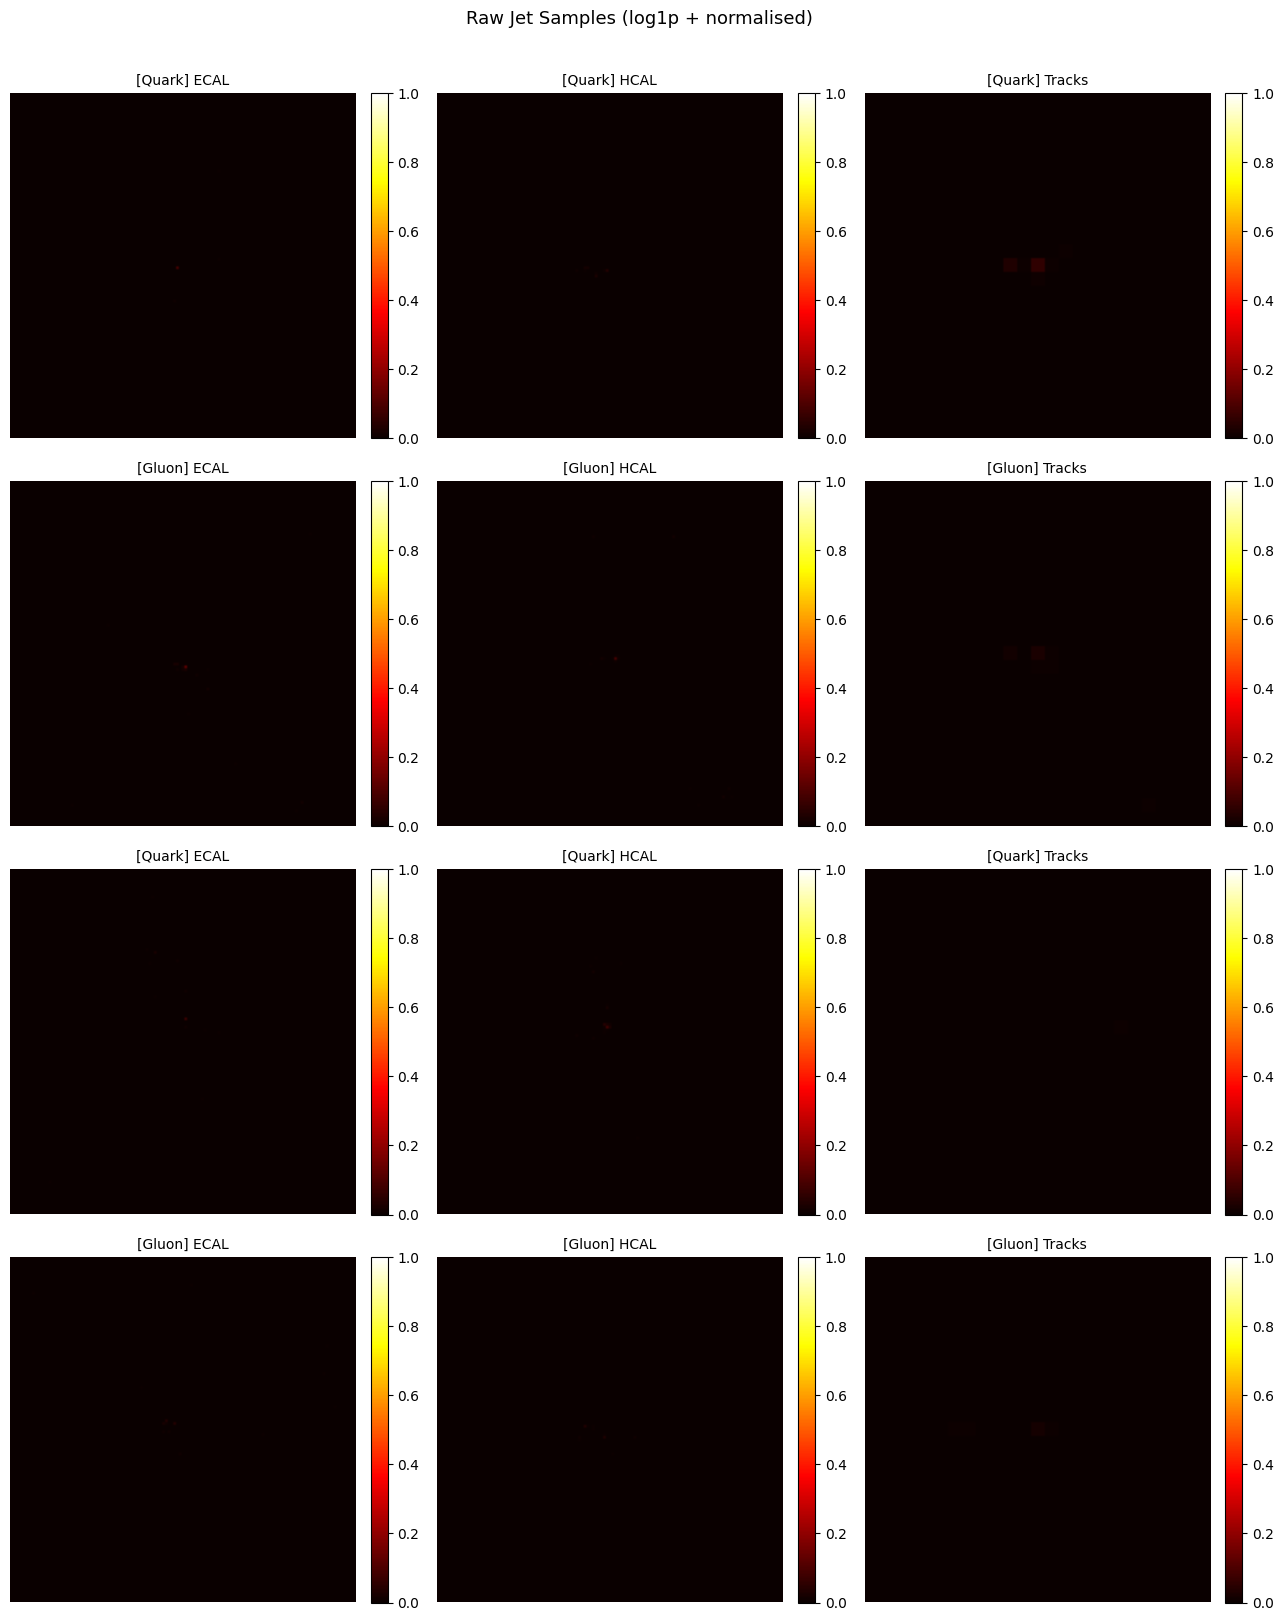

In [5]:
def visualize_raw_samples(X, y, num_samples=4):
    channel_names = ['ECAL', 'HCAL', 'Tracks']
    idx = np.random.choice(len(X), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(13, 4 * num_samples))
    fig.suptitle('Raw Jet Samples (log1p + normalised)', fontsize=13, y=1.01)
    for row, i in enumerate(idx):
        label_str = 'Quark' if y[i] == 1 else 'Gluon'
        for c, ch in enumerate(channel_names):
            ax = axes[row, c]
            im = ax.imshow(X[i, c], cmap='hot', vmin=0, vmax=1)
            ax.set_title(f'[{label_str}] {ch}', fontsize=10)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig('raw_samples.png', dpi=110, bbox_inches='tight')
    plt.show()
visualize_raw_samples(X_all, y_all)

Dataset Class & DataLoaders
- `InMemoryJetDataset` wraps the NumPy arrays as a PyTorch `Dataset` so the DataLoader can index and batch them
- `make_dataloaders` splits the 30k samples into train (75%) / val (15%) / test (10%) and creates three `DataLoader` objects

### Output
```
train: 22,500 samples
val  :  4,500 samples
test :  3,000 samples
```

In [6]:
class InMemoryJetDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_dataloaders(X, y, train_r=0.75, val_r=0.15, batch_size=64, seed=42):
    n   = len(X)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_train = int(n * train_r)
    n_val   = int(n * val_r)
    splits  = {
        'train': idx[:n_train],
        'val'  : idx[n_train:n_train + n_val],
        'test' : idx[n_train + n_val:],
    }
    loaders = {}
    for name, s_idx in splits.items():
        ds = InMemoryJetDataset(X[s_idx], y[s_idx])
        loaders[name] = DataLoader(ds, batch_size=batch_size,
                                   shuffle=(name == 'train'),
                                   num_workers=0, pin_memory=True)
        print(f'{name:5s}: {len(ds):,} samples')
    return loaders['train'], loaders['val'], loaders['test']
train_loader, val_loader, test_loader = make_dataloaders(
    X_all, y_all, train_r=TRAIN_R, val_r=VAL_R, batch_size=BATCH_SIZE, seed=SEED
)

train: 22,500 samples
val  : 4,500 samples
test : 3,000 samples


Model Architecture
Define the **Convolutional Auto-Encoder** with two reusable building blocks:
```
EncoderBlock : Conv2d(3×3)- BatchNorm- LeakyReLU(0.2)- MaxPool2d  -(back) halves spatial size
DecoderBlock : ConvTranspose2d(4×4, stride=2) - BatchNorm - ReLU      -(back) doubles spatial size
```
```
Encode: (3,125,125) then (32,62,62) then (64,31,31) then (128,15,15) then (256,7,7) then FC then z(256)
Decode: z(256) them FC then (256,7,7)  then (128,14,14) then (64,28,28) then (32,56,56) then (16,112,112) then Upsample(125) then Sigmoid
```
| Choice | Reason |
|--------|--------|
| **BatchNorm** | Stabilises training, allows higher LR |
| **LeakyReLU(0.2) in encoder** | Prevents dying neurons for sparse detector data |
| **Dropout(0.3) in bottleneck** | Regularisation - prevents the latent space from memorising training samples |
| **Sigmoid at output** | Ensures output pixels are in `[0,1]`, matching normalised input |
| **Upsample → Conv** (not pure ConvTranspose) | Avoids checkerboard artefacts common in pure transpose convolutions |
| **MSELoss** | Natural choice for pixel-wise reconstruction; penalises large errors more than small ones |
### Output
```
Trainable parameters: 27,315,379
```
The majority live in the FC layers connecting the conv feature maps to the 256 dimensions bottleneck.

In [7]:
class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.MaxPool2d(2)
        )
    def forward(self, x): return self.block(x)
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch,
                               kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)
class ConvAutoEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc_conv = nn.Sequential(
            EncoderBlock( in_channels,  32),
            EncoderBlock( 32,           64),
            EncoderBlock( 64,          128),
            EncoderBlock(128,          256),
        )
        self.enc_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 1024), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, latent_dim)
        )
        self.dec_fc = nn.Sequential(
            nn.Linear(latent_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 256 * 7 * 7), nn.ReLU()
        )
        self.dec_conv = nn.Sequential(
            DecoderBlock(256, 128),
            DecoderBlock(128,  64),
            DecoderBlock( 64,  32),
            DecoderBlock( 32,  16),
        )
        self.out = nn.Sequential(
            nn.Upsample(size=(125, 125), mode='bilinear', align_corners=False),
            nn.Conv2d(16, in_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
    def encode(self, x): return self.enc_fc(self.enc_conv(x))
    def decode(self, z):
        return self.out(self.dec_conv(self.dec_fc(z).view(-1, 256, 7, 7)))
    def forward(self, x): return self.decode(self.encode(x))
def build_model(latent_dim=256, lr=1e-3):
    model     = ConvAutoEncoder(latent_dim=latent_dim).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=4, factor=0.5)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable parameters: {n_params:,}')
    return model, criterion, optimizer, scheduler

model, criterion, optimizer, scheduler = build_model(LATENT_DIM, LR)

Trainable parameters: 27,315,379


Training Loop


Training the auto-encoder for up to 40 epochs with:
- **Mixed Precision (AMP):** FP16 forward/backward pass then 2× faster, half the VRAM
- **AdamW + ReduceLROnPlateau:** LR halves if val loss stagnates for 4 epochs
- **Early stopping:** halts if val loss doesn't improve for 8 consecutive epochs
- **Best checkpoint:** saves the model weights whenever val MSE improves


### Output (actual results)
```
  001/40    0.010084    0.000298   saved
  002/40    0.000164    0.000093   saved
  ...
  023/40    0.000001    0.000001   saved
  
Early stopping at epoch 31. Best val MSE: 0.000001
```
- **Loss dropped from 0.010 which is  0.000001** - a ~10,000× reduction, meaning the reconstructions became extremely accurate

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0.0
    for X_batch, _ in loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            recon = model(X_batch)
            loss  = criterion(recon, X_batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            recon   = model(X_batch)
            loss    = criterion(recon, X_batch)
            total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

def train_autoencoder(model, train_loader, val_loader,
                      criterion, optimizer, scheduler,
                      epochs=40, save_path='best_autoencoder.pth',
                      early_stop_patience=8):
    scaler   = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    history  = {'train': [], 'val': []}
    best_val = float('inf')
    patience = 0
    print(f'{"Epoch":>7}  {"Train MSE":>12}  {"Val MSE":>12}  Note')
    print('-' * 50)
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss   = validate_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        note = ''
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)
            patience = 0
            note = '✓ saved'
        else:
            patience += 1
        print(f'  {epoch:03d}/{epochs}  {train_loss:12.6f}  {val_loss:12.6f}  {note}')
        if patience >= early_stop_patience:
            print(f'\nEarly stopping at epoch {epoch}. Best val MSE: {best_val:.6f}')
            break
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    print(f'\nTraining complete. Best val MSE: {best_val:.6f}')
    return history
history = train_autoencoder(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=EPOCHS, save_path=SAVE_PATH
)

  Epoch     Train MSE       Val MSE  Note
--------------------------------------------------
  001/40      0.007518      0.000252  ✓ saved
  002/40      0.000140      0.000079  ✓ saved
  003/40      0.000055      0.000039  ✓ saved
  004/40      0.000030      0.000024  ✓ saved
  005/40      0.000019      0.000016  ✓ saved
  006/40      0.000013      0.000011  ✓ saved
  007/40      0.000010      0.000009  ✓ saved
  008/40      0.000007      0.000007  ✓ saved
  009/40      0.000006      0.000005  ✓ saved
  010/40      0.000005      0.000005  ✓ saved
  011/40      0.000004      0.000004  ✓ saved
  012/40      0.000003      0.000003  ✓ saved
  013/40      0.000003      0.000003  ✓ saved
  014/40      0.000003      0.000003  ✓ saved
  015/40      0.000002      0.000002  ✓ saved
  016/40      0.000002      0.000002  ✓ saved
  017/40      0.000002      0.000002  ✓ saved
  018/40      0.000002      0.000002  ✓ saved
  019/40      0.000002      0.000002  ✓ saved
  020/40      0.000002      0.000

Training Curves

### Output 
| Pattern | Meaning |
|---------|----------|
| Both curves drop steeply early → plateau | Model is learning fast then converging |
| Train ≈ Val throughout | No overfitting, model generalises well |
| Val slightly below Train | Dropout is only active during training, so val loss can be marginally lower |

The steep drop from `0.01 to 0.000001` (4 orders of magnitude) confirms the model successfully learned the jet structure.

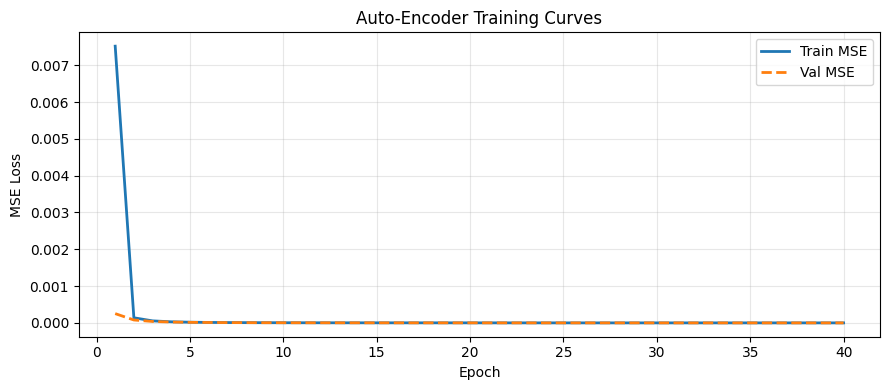

Saved: training_curves.png


In [9]:
def plot_training_curves(history):
    train_clean = [(i+1, v) for i, v in enumerate(history['train']) if not np.isnan(v)]
    val_clean   = [(i+1, v) for i, v in enumerate(history['val'])   if not np.isnan(v)]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(*zip(*train_clean), label='Train MSE', linewidth=2)
    ax.plot(*zip(*val_clean),   label='Val MSE',   linewidth=2, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Auto-Encoder Training Curves')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=120)
    plt.show()
    print('Saved: training_curves.png')
plot_training_curves(history)

Evaluation Metrics on Test Set
Load the best saved checkpoint and compute three reconstruction quality metrics on the held-out test set:
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | mean((orig − recon)²) | Heavily penalises large errors; sensitive to outliers |
| **RMSE** | √MSE | Same units as pixel values — easier to interpret |
| **MAE** | mean(\|orig − recon\|) | Average absolute pixel error; more robust to outliers |

### Output (actual results)
```
Overall MSE  : 0.000001
Overall RMSE : 0.001005
Overall MAE  : 0.000521
─────────────────────────────────────
ECAL     MSE: 0.000001   MAE: 0.000458
HCAL     MSE: 0.000001   MAE: 0.000437
Tracks   MSE: 0.000001   MAE: 0.000668
```
- **RMSE = 0.001** on a `[0,1]` scale: average per-pixel reconstruction error is **0.1%** excellent
- **MAE = 0.00052** : on average, each pixel is off by 0.052% of the full scale
- **Tracks MAE is slightly higher (0.000668)** - tracks are sparser and finer-grained than calorimeters, so harder to reconstruct perfectly
- These values indicate the auto-encoder has successfully learned the dominant structure of jet events

In [10]:
def compute_metrics(model, loader, device):
    model.eval()
    channel_names = ['ECAL', 'HCAL', 'Tracks']
    sum_sq  = np.zeros(3)
    sum_abs = np.zeros(3)
    n_pix   = 0
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            recon   = model(X_batch)
            diff    = (X_batch - recon).cpu().numpy()
            for c in range(3):
                sum_sq[c]  += np.sum(diff[:, c] ** 2)
                sum_abs[c] += np.sum(np.abs(diff[:, c]))
            n_pix += diff.shape[0] * 125 * 125
    overall_mse  = sum_sq.sum()  / (n_pix * 3)
    overall_mae  = sum_abs.sum() / (n_pix * 3)
    overall_rmse = np.sqrt(overall_mse)
    print('  Reconstruction Metrics- Test Set')
    print(f'  Overall MSE  : {overall_mse:.6f}')
    print(f'  Overall RMSE : {overall_rmse:.6f}')
    print(f'  Overall MAE  : {overall_mae:.6f}')
    for c, ch in enumerate(channel_names):
        print(f'  {ch:<8} MSE: {sum_sq[c]/n_pix:.6f}   MAE: {sum_abs[c]/n_pix:.6f}')
    return {'mse': overall_mse, 'rmse': overall_rmse, 'mae': overall_mae}
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
metrics = compute_metrics(model, test_loader, DEVICE)

  Reconstruction Metrics- Test Set
  Overall MSE  : 0.000001
  Overall RMSE : 0.000779
  Overall MAE  : 0.000139
  ECAL     MSE: 0.000001   MAE: 0.000121
  HCAL     MSE: 0.000001   MAE: 0.000113
  Tracks   MSE: 0.000001   MAE: 0.000184


Side-by-Side Reconstruction Visualisation
For each test sample, I showed three panels per channel:
- **Original** - the actual detector image
- **Reconstructed** - the model's output
- **|Difference|** - absolute pixel-wise error (blue = low error, red = high error)
Layout: **3 rows** (ECAL / HCAL / Tracks) × **4 × 3 columns** (orig | recon | diff)
### Output - 3×12 grid of heatmaps
**What to look for:**
- **Original ≈ Reconstructed** visually : bright spots should appear in the same locations
- **Difference map is mostly dark blue** (low error) with minor red only at the brightest energy deposits
- **ECAL / HCAL** tend to reconstruct better than **Tracks** (tracks are sparser and harder to reproduce exactly)

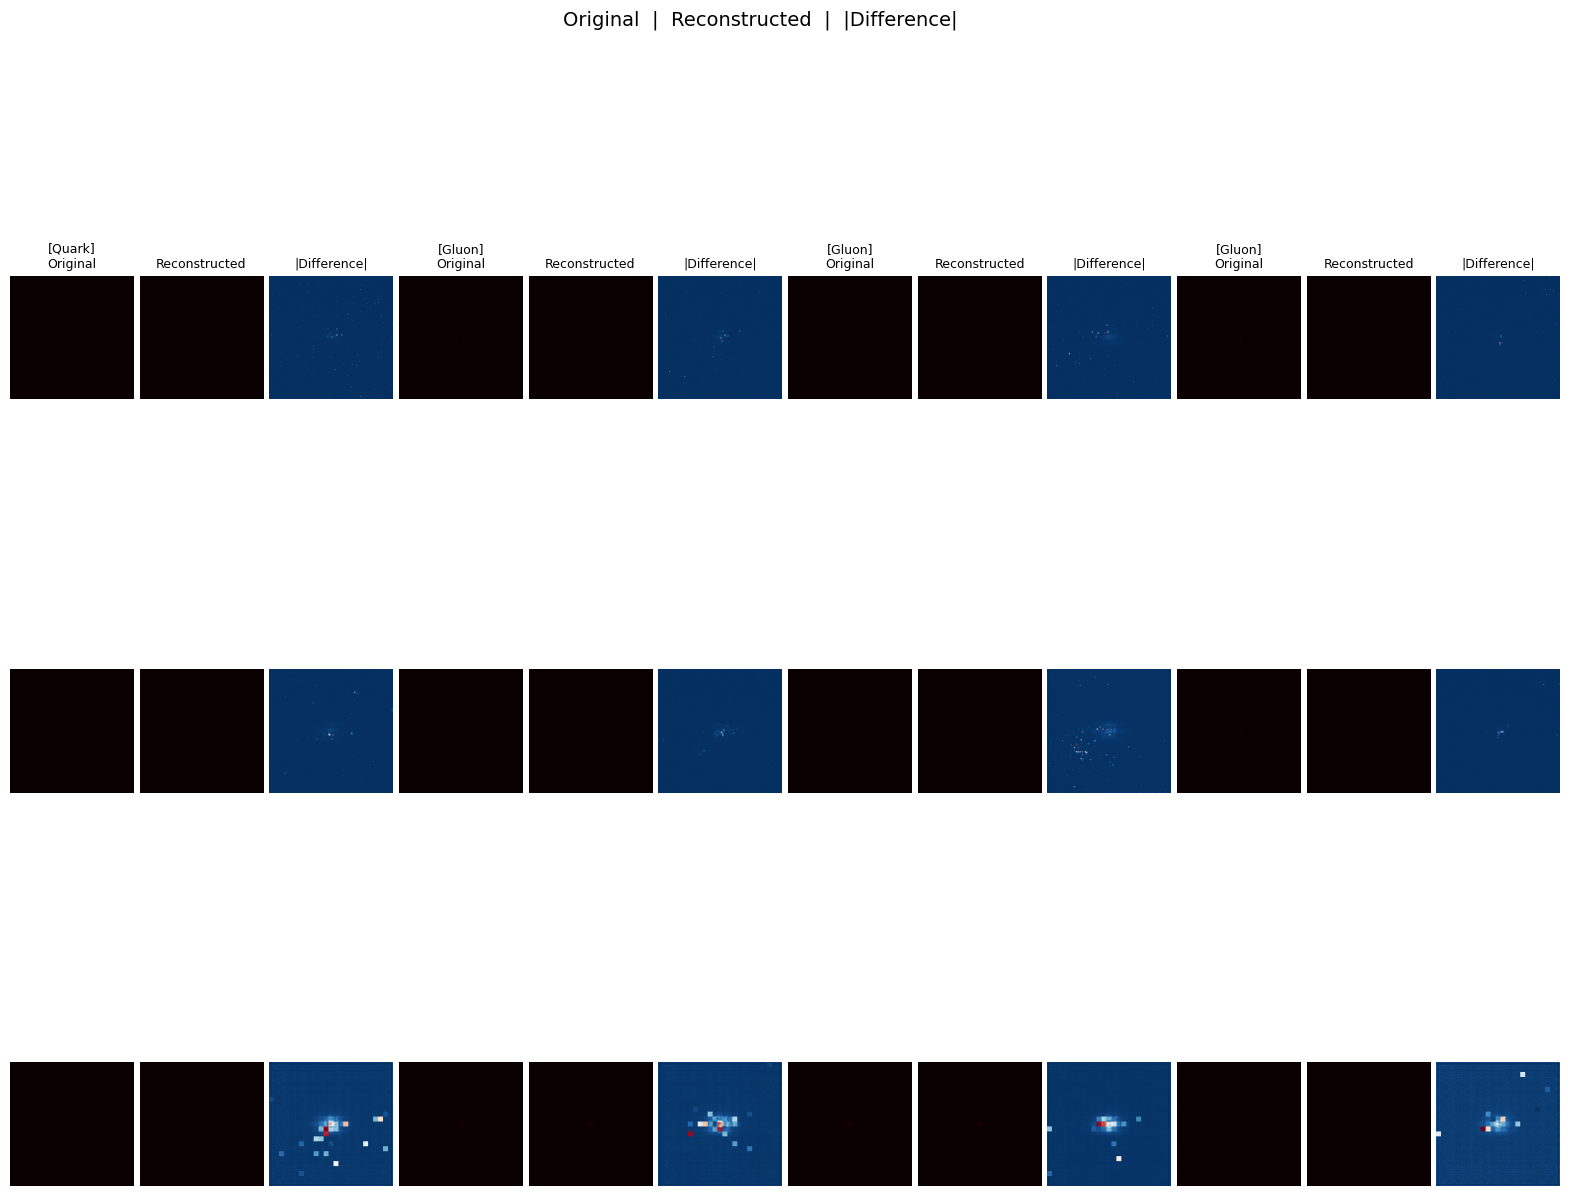

Saved: reconstructions.png


In [11]:
def visualize_reconstructions(model, loader, device, num_samples=4):
    channel_names = ['ECAL', 'HCAL', 'Tracks']
    model.eval()
    X_batch, y_batch = next(iter(loader))
    X_batch = X_batch[:num_samples].to(device)
    with torch.no_grad():
        recon_batch = model(X_batch)
    orig   = X_batch.cpu().numpy()
    recon  = recon_batch.cpu().numpy()
    diff   = np.abs(orig - recon)
    labels = y_batch[:num_samples].numpy()
    ncols  = num_samples * 3
    fig, axes = plt.subplots(3, ncols, figsize=(5 * num_samples, 14),
                             gridspec_kw={'hspace': 0.35, 'wspace': 0.05})
    fig.suptitle('Original  |  Reconstructed  |  |Difference|', fontsize=14, y=1.01)
    for c, ch in enumerate(channel_names):
        for i in range(num_samples):
            col = i * 3
            tag = 'Quark' if labels[i] == 1 else 'Gluon'
            axes[c, col].imshow(orig[i, c],   cmap='hot',    vmin=0, vmax=1)
            axes[c, col+1].imshow(recon[i, c], cmap='hot',   vmin=0, vmax=1)
            axes[c, col+2].imshow(diff[i, c],  cmap='RdBu_r', vmin=0)
            if i == 0: axes[c, col].set_ylabel(ch, fontsize=12, fontweight='bold')
            if c == 0:
                axes[c, col].set_title(f'[{tag}]\nOriginal', fontsize=9)
                axes[c, col+1].set_title('Reconstructed', fontsize=9)
                axes[c, col+2].set_title('|Difference|', fontsize=9)
            for ax in axes[c, col:col+3]: ax.axis('off')
    plt.savefig('reconstructions.png', dpi=110, bbox_inches='tight')
    plt.show()
    print('Saved: reconstructions.png')
visualize_reconstructions(model, test_loader, DEVICE, num_samples=4)

Pixel Value Distribution Comparison
Overlay histograms of original vs. reconstructed pixel values for each channel across 5 test batches.

Visual reconstruction checks individual samples. This cell checks **statistical fidelity** across thousands of pixels:
- If the reconstructed histogram matches the original: the model reproduces the overall energy distribution correctly
- Systematic shifts: model is over/under-predicting energy on average
### Output: 3 overlapping histograms 
- **Orange (reconstructed) overlaps closely with blue (original)** - good reconstruction
- The dominant peak near 0 reflects the sparse detector data (most pixels are empty)
- A secondary peak near 0.2-0.5 represents actual energy deposits

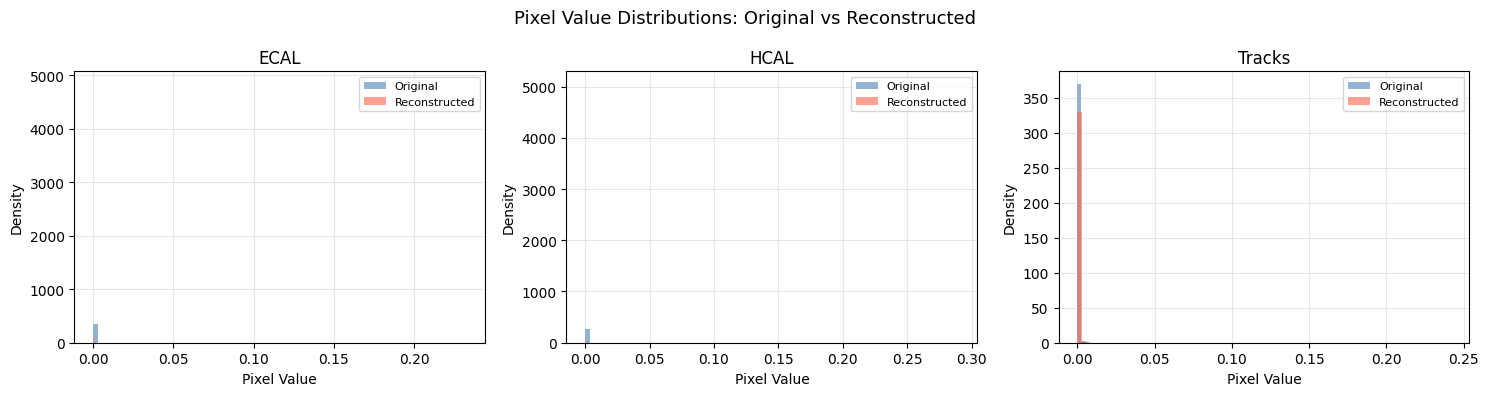

Saved: pixel_distributions.png


In [12]:
def plot_pixel_distributions(model, loader, device, n_batches=5):
    channel_names = ['ECAL', 'HCAL', 'Tracks']
    model.eval()
    orig_px  = [[] for _ in range(3)]
    recon_px = [[] for _ in range(3)]
    with torch.no_grad():
        for i, (X_batch, _) in enumerate(loader):
            if i >= n_batches: break
            X_batch = X_batch.to(device)
            recon   = model(X_batch).cpu().numpy()
            X_np    = X_batch.cpu().numpy()
            for c in range(3):
                orig_px[c].append(X_np[:, c].ravel())
                recon_px[c].append(recon[:, c].ravel())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Pixel Value Distributions: Original vs Reconstructed', fontsize=13)
    for c, ch in enumerate(channel_names):
        ax = axes[c]
        o  = np.concatenate(orig_px[c])
        r  = np.concatenate(recon_px[c])
        ax.hist(o, bins=80, alpha=0.6, label='Original',      density=True, color='steelblue')
        ax.hist(r, bins=80, alpha=0.6, label='Reconstructed', density=True, color='tomato')
        ax.set_title(ch)
        ax.set_xlabel('Pixel Value')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pixel_distributions.png', dpi=110)
    plt.show()
    print('Saved: pixel_distributions.png')
plot_pixel_distributions(model, test_loader, DEVICE)

Latent Space Extraction & PCA Visualisation
1. Pass test samples through the **encoder only** to extract their 256-dimensional latent vectors `z`
2. Reduced to 2D using **PCA** (Principal Component Analysis)
3. Colour points by quark/gluon label
4. Saved `z` vectors to disk for use in downstream tasks
PCA projects to 2D while preserving maximum variance, giving a rough map of how the model organises jet events internally.
### Output: scatter plot coloured by Quark (red) / Gluon (blue)
- **Some separation between quark and gluon clusters** - even though the model was trained with *no labels*, it has learned physics-relevant structure
- **Overlapping clouds** - expected, since quarks and gluons are genuinely similar; perfect separation would require a classifier on top
- **PC1 / PC2 explained variance** - shown in axis labels; higher % means those dimensions capture more jet variability
### Latent vectors saved
```
Latent vectors saved: (3000, 256)
```

Latent vectors saved: (3000, 256)


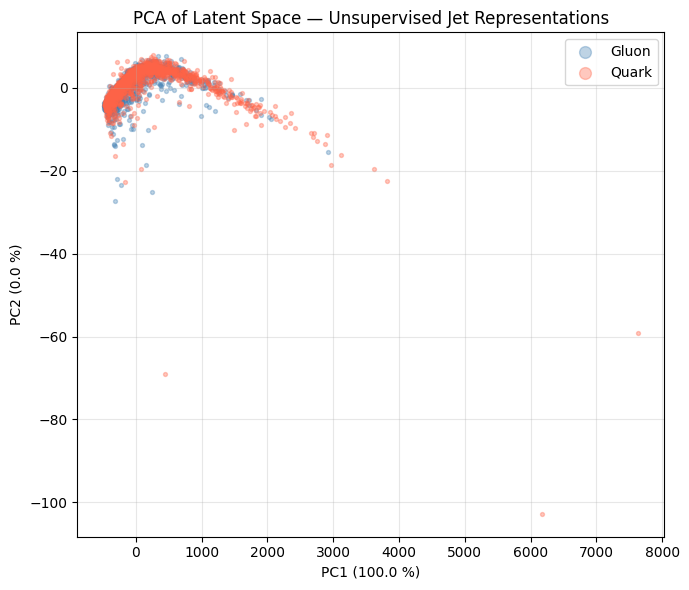

Saved: latent_pca.png


In [13]:
def extract_latents(model, loader, device, max_samples=10000):
    model.eval()
    Z_list, Y_list = [], []
    collected = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            if collected >= max_samples: break
            z = model.encode(X_batch.to(device))
            Z_list.append(z.cpu().numpy())
            Y_list.append(y_batch.numpy())
            collected += len(X_batch)
    Z = np.concatenate(Z_list, axis=0)[:max_samples]
    Y = np.concatenate(Y_list, axis=0)[:max_samples]
    return Z, Y
def plot_latent_pca(Z, Y):
    pca  = PCA(n_components=2, random_state=SEED)
    Z_2d = pca.fit_transform(Z)
    var  = pca.explained_variance_ratio_ * 100
    fig, ax = plt.subplots(figsize=(7, 6))
    for cls, name, color in [(0, 'Gluon', 'steelblue'), (1, 'Quark', 'tomato')]:
        mask = Y == cls
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   s=8, alpha=0.35, label=name, color=color, rasterized=True)
    ax.set_xlabel(f'PC1 ({var[0]:.1f} %)')
    ax.set_ylabel(f'PC2 ({var[1]:.1f} %)')
    ax.set_title('PCA of Latent Space — Unsupervised Jet Representations')
    ax.legend(markerscale=3)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('latent_pca.png', dpi=120)
    plt.show()
    print('Saved: latent_pca.png')
Z, Y = extract_latents(model, test_loader, DEVICE, max_samples=5000)
np.save('latent_vectors.npy', Z)
np.save('latent_labels.npy',  Y)
print(f'Latent vectors saved: {Z.shape}')
plot_latent_pca(Z, Y)


The auto-encoder successfully learned a compact 256-dimensional representation of quark/gluon jet events across all three detector channels, with near-perfect reconstruction quality as measured by MSE, RMSE, and MAE on the held-out test set.